In [1]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import os

In [2]:
# ── Config ──────────────────────────────────────────
DATA_DIR = "dataset"
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 2
LR = 0.001
EPOCHS = 10
PATIENCE = 5
SAVE_PATH = "mask_detector.pth"
device = torch.device("cuda")

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=20),

    transforms.ColorJitter(brightness=0.5),

    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),

    transforms.ToTensor(),

    transforms.Lambda(lambda x: x + 0.02 * torch.randn_like(x))
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])


In [4]:
train_dataset = datasets.ImageFolder("dataset/train", transform=train_transform)
val_dataset   = datasets.ImageFolder("dataset/val", transform=val_transform)
test_dataset  = datasets.ImageFolder("dataset/test", transform=test_transform)

print("Classes:", train_dataset.classes)

Classes: ['WithMask', 'WithoutMask']


In [5]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
model = models.mobilenet_v2(weights="DEFAULT")

model.classifier[1] = nn.Linear(model.last_channel, 2)

model = model.to(device)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [8]:
best_val_loss = float("inf")
counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ================= TRAIN =================
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    # ================= VALIDATION =================
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # ================= SAVE METRICS =================
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    # ================= EARLY STOPPING =================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print("Model saved!")
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping triggered!")
            break


Epoch 1/10
Train Loss: 0.0542 | Acc: 0.9827
Val   Loss: 0.3440 | Acc: 0.7950
Model saved!

Epoch 2/10
Train Loss: 0.0286 | Acc: 0.9900
Val   Loss: 0.0798 | Acc: 0.9663
Model saved!

Epoch 3/10
Train Loss: 0.0232 | Acc: 0.9923
Val   Loss: 0.0138 | Acc: 0.9938
Model saved!

Epoch 4/10
Train Loss: 0.0202 | Acc: 0.9935
Val   Loss: 0.0069 | Acc: 0.9975
Model saved!

Epoch 5/10
Train Loss: 0.0181 | Acc: 0.9932
Val   Loss: 0.0258 | Acc: 0.9912

Epoch 6/10
Train Loss: 0.0189 | Acc: 0.9935
Val   Loss: 0.0135 | Acc: 0.9950

Epoch 7/10
Train Loss: 0.0133 | Acc: 0.9954
Val   Loss: 0.0056 | Acc: 0.9975
Model saved!

Epoch 8/10
Train Loss: 0.0159 | Acc: 0.9950
Val   Loss: 0.0174 | Acc: 0.9888

Epoch 9/10
Train Loss: 0.0092 | Acc: 0.9967
Val   Loss: 0.0134 | Acc: 0.9962

Epoch 10/10
Train Loss: 0.0110 | Acc: 0.9956
Val   Loss: 0.0251 | Acc: 0.9938


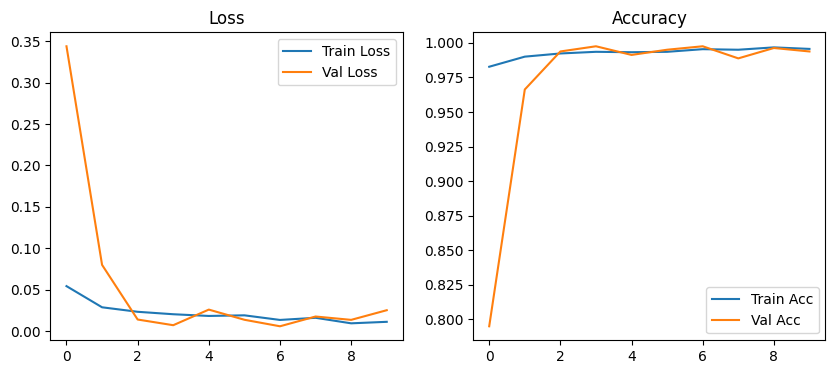

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.show()